# Lateral–Torsional Buckling — simply-supported I-beam, uniform moment

Same *geometric-nonlinearity-only* recipe as the chevron `buckleUP`
notebooks, now applied to the classical **lateral-torsional buckling**
(LTB) problem of a slender I-section beam in pure bending:

1. Build a single straight beam as one `add_line` call
2. Retrofit a **half-sine lateral imperfection** with `replace_line`
   (amplitude `L/1000`, direction = weak axis = global Y)
3. Emit the beam as 3-D `elasticBeamColumn` elements with a
   **`Corotational`** transformation — no material nonlinearity
4. Apply equal-and-opposite end moments so the beam sees a **uniform**
   strong-axis moment `M` over its full length
5. Sweep `M` in load control until the lateral deflection and twist
   amplify dramatically approaching the critical moment

### Why this captures LTB without modelling plasticity

LTB is a *geometric* instability: under strong-axis bending the
compression flange tends to drift laterally, which generates a
twisting moment on the cross-section, which amplifies the lateral
drift, which amplifies the twist… a classic coupled Euler-type mode.
Corotational finite rotations already model that coupling at the
element level — we do not need plasticity or any special LTB element.
The only ingredient the elastic formulation cannot supply by itself
is the **seed**: a perfectly straight beam stays perfectly straight
forever. A tiny lateral imperfection is that seed.

### Classical reference

For a simply-supported beam in pure uniform moment (no warping),

$$
M_{\mathrm{cr}} \;=\; \frac{\pi}{L_b}\,\sqrt{E\,I_{\text{weak}} \; G\,J}
$$

where `L_b` is the unbraced length, `I_weak` is the cross-section
moment of inertia about the **weak** axis, and `GJ` is the
St.-Venant torsional rigidity. The full Timoshenko formula adds a
`(π²/L²) · EI_weak · EC_w` warping term under the root — for the
W-section here that correction is ~15% and the FEM (which does **not**
carry warping stiffness in `elasticBeamColumn`) will track the
warping-free version cleanly.

In [1]:
from apeGmsh import apeGmsh, Results
import numpy as np
import matplotlib.pyplot as plt

# ---- Steel material ----------------------------------------------
E   = 200_000.0              # MPa
nu  = 0.3
G   = E / (2.0 * (1 + nu))

# ---- W-section geometry [mm] -------------------------------------
bf      = 150.0    # flange width
tf      = 12.0     # flange thickness
h_total = 300.0    # overall depth (web + 2 flanges)
tw      = 8.0      # web thickness
h_web   = h_total - 2 * tf

# ---- Derived section properties ----------------------------------
A  = 2 * bf * tf + h_web * tw
# Strong axis (local y in OpenSees): bending in the vertical plane.
I_strong = (2 * (bf * tf ** 3 / 12.0
                 + bf * tf * ((h_web + tf) / 2.0) ** 2)
            + tw * h_web ** 3 / 12.0)
# Weak axis (local z in OpenSees): bending in the horizontal plane.
I_weak   = 2 * (tf * bf ** 3 / 12.0) + h_web * tw ** 3 / 12.0
# Thin-walled open-section St.-Venant torsion constant.
J = (2 * bf * tf ** 3 + h_web * tw ** 3) / 3.0

# ---- Beam geometry -----------------------------------------------
L  = 6000.0     # unbraced length [mm]
lc = 150.0      # mesh size
delta_0 = L / 1000.0    # lateral imperfection amplitude

# ---- Classical LTB critical moment (no warping) ------------------
M_cr = (np.pi / L) * np.sqrt(E * I_weak * G * J)

print(f'Section W{h_total:.0f}x{int(bf)}x{int(tf)}')
print(f'  A        = {A:.0f} mm^2')
print(f'  I_strong = {I_strong:.3e} mm^4  (bending about strong axis)')
print(f'  I_weak   = {I_weak:.3e} mm^4    (bending about weak axis)')
print(f'  J        = {J:.0f} mm^4')
print(f'  I_strong / I_weak = {I_strong/I_weak:.1f}  '
      f'(larger is more LTB-prone)')
print()
print(f'Unbraced length L_b = {L:.0f} mm, imperfection L/1000 = {delta_0:.2f} mm')
print(f'M_cr (no warping)   = {M_cr/1e6:.2f} kN*m')

Section W300x150x12
  A        = 5808 mm^2
  I_strong = 8.871e+07 mm^4  (bending about strong axis)
  I_weak   = 6.762e+06 mm^4    (bending about weak axis)
  J        = 219904 mm^4
  I_strong / I_weak = 13.1  (larger is more LTB-prone)

Unbraced length L_b = 6000 mm, imperfection L/1000 = 6.00 mm
M_cr (no warping)   = 79.19 kN*m


## 1. Build the beam, then retrofit a half-sine lateral imperfection

The beam runs along the global X axis with the cross-section's
**strong axis vertical** (global Z). The weak axis — the one LTB
bows about — is therefore global Y. `replace_line` with
`direction=(0, 1, 0)` auto-projects that hint perpendicular to the
beam axis and places 15 interior points on a half-sine envelope of
amplitude `δ₀ = L/1000`.

In [2]:
m = apeGmsh(model_name='LTB_uniform', verbose=False)
m.begin()

p_pin  = m.model.geometry.add_point(0, 0, 0, lc=lc, label='pin')
p_roll = m.model.geometry.add_point(L, 0, 0, lc=lc, label='roller')

# Plain clean build first.
beam = m.model.geometry.add_line(p_pin, p_roll, label='beam')
m.physical.add_curve(tags=[beam], name='pg_beam')

# Retrofit with a half-sine imperfection in the weak-axis direction.
seg_tags = m.model.geometry.replace_line(
    beam,
    magnitude=delta_0,
    direction=(0, 1, 0),       # weak-axis lateral (global Y)
    shape='sine',
    n_segments=16,
)
print(f'beam replaced with {len(seg_tags)} sine segments: {seg_tags}')

m.mesh.sizing.set_global_size(lc)
m.mesh.generation.generate(dim=1)

fem = m.mesh.queries.get_fem_data(remove_orphans=True)
m.end()

print(f'nodes: {len(fem.nodes.ids)}')
for g in fem.elements:
    print(f'  {g.type_name:6s} n={len(g)}')

beam replaced with 16 sine segments: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
nodes: 49
  line2  n=48
  point1 n=17


## 2. Inspect the imperfection

Walk every beam mesh node from pin to roller and compute the
perpendicular offset to the straight `(0,0,0) → (L,0,0)` axis.
Overlay the analytical half-sine envelope `δ₀·sin(π·x/L)` as a sanity
check.

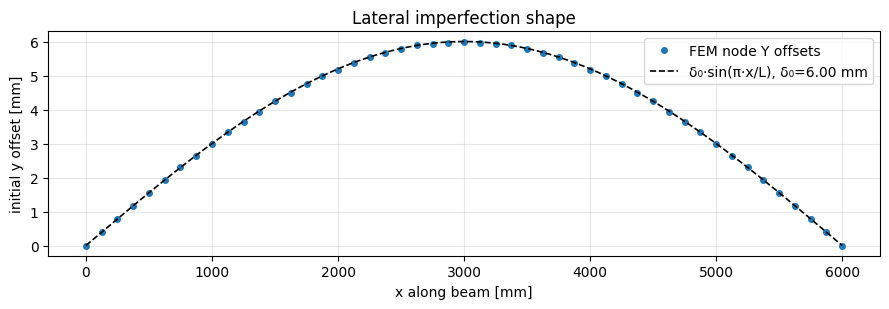

max FEM y offset = 6.0000 mm  (theory = 6.0000 mm)
max FEM z offset = 0.0000 mm  (should be 0)


In [3]:
beam_ids    = np.array(
    [int(n) for n in fem.nodes.get_ids(target='pg_beam')])
beam_coords = fem.nodes.get_coords(target='pg_beam')

order = np.argsort(beam_coords[:, 0])
beam_ids    = beam_ids[order]
beam_coords = beam_coords[order]

xs  = beam_coords[:, 0]
uy0 = beam_coords[:, 1]    # initial lateral offset (= the imperfection)
uz0 = beam_coords[:, 2]

x_theory = np.linspace(0, L, 300)
y_theory = delta_0 * np.sin(np.pi * x_theory / L)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(xs, uy0, 'o', ms=4, color='tab:blue', label='FEM node Y offsets')
ax.plot(x_theory, y_theory, 'k--', lw=1.2,
        label=f'\u03b4\u2080\u00b7sin(\u03c0\u00b7x/L), \u03b4\u2080={delta_0:.2f} mm')
ax.set_xlabel('x along beam [mm]')
ax.set_ylabel('initial y offset [mm]')
ax.set_title('Lateral imperfection shape')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f'max FEM y offset = {uy0.max():.4f} mm  (theory = {delta_0:.4f} mm)')
print(f'max FEM z offset = {abs(uz0).max():.4f} mm  (should be 0)')

## 3. Emit the 3-D OpenSees model

**`ndm=3, ndf=6`** for the rotational DOFs that LTB requires.

* **Cross-section orientation**: `geomTransf('Corotational', 1, 0, 0, 1)`
  places the local z axis along global Z (vertical) and the local y
  axis along global Y (horizontal/weak). The `elasticBeamColumn`
  argument order `(A, E, G, J, Iy, Iz, transf)` then takes `Iy = I_strong`
  (bending about local y = strong-axis bending) and `Iz = I_weak`.
* **Simply-supported fork support**: both ends have all three
  translations locked *except* the roller's axial DOF (free to let
  the beam stretch/shorten under moment-induced fibre strains), and
  both ends have the torsional DOF (rx) locked. The bending rotations
  (ry, rz) are left free so the beam can curve.
* **No material nonlinearity** — `elasticBeamColumn` is linear-elastic
  in the cross-section. The buckling comes entirely from the
  corotational finite-rotation kinematics.

In [4]:
import openseespy.opensees as ops

ops.wipe()
ops.model('basic', '-ndm', 3, '-ndf', 6)
ops.timeSeries('Linear', 1)

for nid, xyz in fem.nodes.get():
    ops.node(int(nid), float(xyz[0]), float(xyz[1]), float(xyz[2]))

pin_id  = int(fem.nodes.get_ids(target='pin')[0])
roll_id = int(fem.nodes.get_ids(target='roller')[0])

# Fork supports:
#   pin    — ux, uy, uz fixed;         rx fixed; ry, rz free
#   roller — ux free; uy, uz fixed;    rx fixed; ry, rz free
ops.fix(pin_id,  1, 1, 1,  1, 0, 0)
ops.fix(roll_id, 0, 1, 1,  1, 0, 0)

# Local-z along global Z so bending about local-y = strong-axis.
ops.geomTransf('Corotational', 1, 0, 0, 1)

n_elem = 0
for group in fem.elements.get(element_type='line2'):
    for eid, conn in group:
        ops.element(
            'elasticBeamColumn', int(eid),
            int(conn[0]), int(conn[1]),
            A, E, G, J, I_strong, I_weak, 1,
        )
        n_elem += 1

print(f'elasticBeamColumn elements: {n_elem}')

elasticBeamColumn elements: 48


## 4. Apply equal-and-opposite end moments and sweep

For a **uniform** moment along the span we apply `+My` at the pin
and `−My` at the roller. Equilibrium then gives `M(x) = M_applied`
everywhere between them. The integrator advances the load factor so
the applied moment is just `(step+1) * dM`.

As `M` approaches the critical moment the lateral deflection and the
twist at midspan should both amplify sharply — classical LTB.

In [5]:
# Reference load = unit moment (Nm in each pattern).
ops.pattern('Plain', 1, 1)
ops.load(pin_id,  0, 0, 0,  0, +1.0, 0)    # +My at pin
ops.load(roll_id, 0, 0, 0,  0, -1.0, 0)    # -My at roller

ops.constraints('Transformation')
ops.numberer('RCM')
ops.system('UmfPack')
ops.test('NormDispIncr', 1.0e-7, 200)
ops.algorithm('Newton')

M_target = 0.95 * M_cr
n_steps  = 50
dM       = M_target / n_steps
ops.integrator('LoadControl', dM)
ops.analysis('Static')

# Midspan tracking node (closest to x = L/2 in the original mesh).
mid_idx = int(np.argmin(np.abs(xs - L / 2.0)))
mid_nid = int(beam_ids[mid_idx])
print(f'midspan node = {mid_nid} at x = {xs[mid_idx]:.1f} mm')

hist_M       = []
hist_uy      = []
hist_uz      = []
hist_twist   = []
disp_per_step: list[np.ndarray] = []
twist_per_step: list[np.ndarray] = []
n_nodes = len(fem.nodes.ids)

for step in range(n_steps):
    ok = ops.analyze(1)
    if ok != 0:
        print(f'analysis failed at step {step + 1}')
        break
    M_now = (step + 1) * dM
    d = ops.nodeDisp(mid_nid)
    # d = [ux, uy, uz, rx, ry, rz] — rx is the longitudinal-axis twist.
    hist_M.append(M_now)
    hist_uy.append(d[1])
    hist_uz.append(d[2])
    hist_twist.append(d[3])

    # Capture the full 3-D displacement + per-node twist for the viewer.
    d_full = np.zeros((n_nodes, 3), dtype=np.float64)
    t_full = np.zeros(n_nodes, dtype=np.float64)
    for i, nid in enumerate(fem.nodes.ids):
        di = ops.nodeDisp(int(nid))
        d_full[i, 0] = di[0]
        d_full[i, 1] = di[1]
        d_full[i, 2] = di[2]
        t_full[i]    = di[3]          # rx = twist about beam axis
    disp_per_step.append(d_full)
    twist_per_step.append(t_full)

print(f'converged in {len(hist_M)} of {n_steps} steps')
print(f'final M       = {hist_M[-1]/1e6:.3f} kN*m '
      f'({hist_M[-1]/M_cr*100:.1f}% M_cr)')
print(f'final uy mid  = {hist_uy[-1]:+.3f} mm  '
      f'(amplification \u03b4\u2080 \u2192 uy \u2248 '
      f'{(delta_0 + hist_uy[-1])/delta_0:.2f}x)')
print(f'final uz mid  = {hist_uz[-1]:+.3f} mm  (strong-axis bending)')
print(f'final twist   = {hist_twist[-1]:+.4e} rad  '
      f'({np.degrees(hist_twist[-1]):+.2f} deg)')

midspan node = 10 at x = 3000.0 mm


converged in 50 of 50 steps
final M       = 75.234 kN*m (95.0% M_cr)
final uy mid  = +27.735 mm  (amplification δ₀ → uy ≈ 5.62x)
final uz mid  = -23.491 mm  (strong-axis bending)
final twist   = -1.5004e-01 rad  (-8.60 deg)


## 5. Amplification curves vs. Perry-like envelope

LTB is a *coupled* (lateral + twist) buckling mode, so the classical
Perry formula `δ(P) = δ₀/(1-P/P_cr)` is an **envelope** rather than an
exact match — but the asymptote at `M_cr` is the same. We plot:

* **M vs lateral uy** (Perry envelope `δ₀/(1−M/M_cr)`)
* **M vs twist** (from the FEM)
* **M vs strong-axis uz** (linear until twist kicks in)

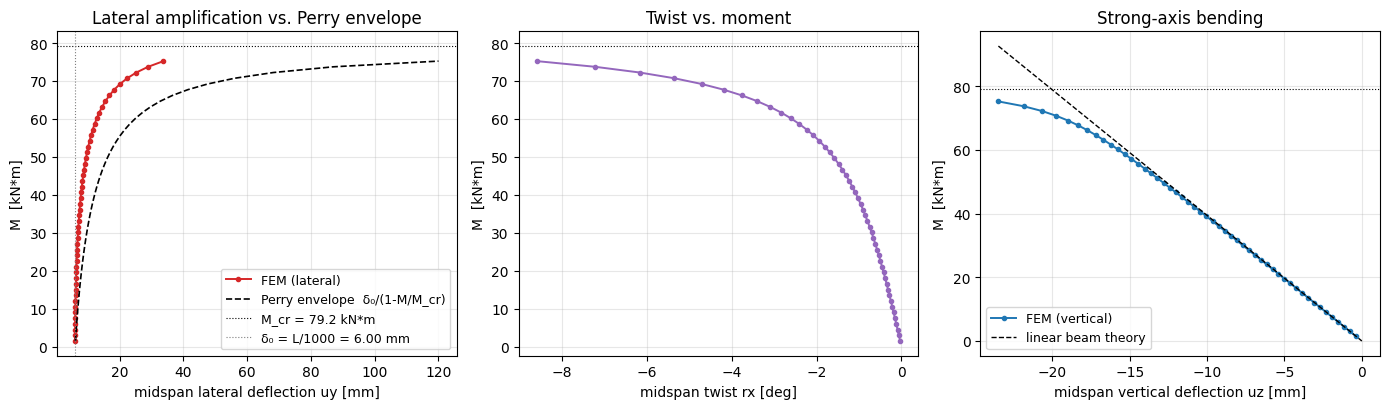

In [6]:
hist_M     = np.asarray(hist_M)
hist_uy    = np.asarray(hist_uy)
hist_uz    = np.asarray(hist_uz)
hist_twist = np.asarray(hist_twist)

# Perry envelope using theoretical M_cr.
eta = hist_M / M_cr
valid = eta < 0.99
uy_theory = delta_0 / (1.0 - eta[valid])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# (a) Lateral deflection
ax = axes[0]
ax.plot(delta_0 + hist_uy, hist_M / 1e6, 'o-', lw=1.4, ms=3,
        color='tab:red', label='FEM (lateral)')
ax.plot(uy_theory, hist_M[valid] / 1e6, 'k--', lw=1.2,
        label='Perry envelope  \u03b4\u2080/(1-M/M_cr)')
ax.axhline(M_cr / 1e6, color='k', lw=0.8, ls=':',
           label=f'M_cr = {M_cr/1e6:.1f} kN*m')
ax.axvline(delta_0, color='tab:gray', lw=0.8, ls=':',
           label=f'\u03b4\u2080 = L/1000 = {delta_0:.2f} mm')
ax.set_xlabel('midspan lateral deflection uy [mm]')
ax.set_ylabel('M  [kN*m]')
ax.set_title('Lateral amplification vs. Perry envelope')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=9)

# (b) Twist
ax = axes[1]
ax.plot(np.degrees(hist_twist), hist_M / 1e6, 'o-', lw=1.4, ms=3,
        color='tab:purple')
ax.axhline(M_cr / 1e6, color='k', lw=0.8, ls=':')
ax.set_xlabel('midspan twist rx [deg]')
ax.set_ylabel('M  [kN*m]')
ax.set_title('Twist vs. moment')
ax.grid(True, alpha=0.3)

# (c) Strong-axis vertical deflection (should be roughly linear)
ax = axes[2]
ax.plot(hist_uz, hist_M / 1e6, 'o-', lw=1.4, ms=3, color='tab:blue',
        label='FEM (vertical)')
# Linear reference: M = EI_strong * kappa, kappa = 8*uz/L^2 for a
# uniform-moment simply-supported beam at midspan.
uz_linear_grid = np.linspace(hist_uz.min(), 0, 50)
M_linear_grid  = np.abs(uz_linear_grid) * 8 * E * I_strong / L**2
ax.plot(uz_linear_grid, M_linear_grid / 1e6, 'k--', lw=1.0,
        label='linear beam theory')
ax.axhline(M_cr / 1e6, color='k', lw=0.8, ls=':')
ax.set_xlabel('midspan vertical deflection uz [mm]')
ax.set_ylabel('M  [kN*m]')
ax.set_title('Strong-axis bending')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Time-series viewer with twist contour

Push every load step into `Results.from_fem` as a pseudo-time frame.
Each step carries the displacement vector + three scalars:

* `|U|` — magnitude for contour colouring of the deformed shape
* `Uy` — weak-axis lateral displacement (the one that amplifies)
* `twist_deg` — `rx` converted to degrees, so you can see the
  compression flange progressively rolling out of the vertical plane

In [7]:
steps = []
for M_i, d_step, t_step in zip(hist_M, disp_per_step, twist_per_step):
    u_mag = np.linalg.norm(d_step, axis=1)
    steps.append({
        'time': float(M_i),
        'point_data': {
            'Displacement': d_step,
            '|U|':          u_mag,
            'Uy':           d_step[:, 1],
            'Uz':           d_step[:, 2],
            'twist_deg':    np.degrees(t_step),
        },
    })

print(f'time-series steps: {len(steps)}')
print(f'time range       : {steps[0]["time"]/1e6:.2f} to '
      f'{steps[-1]["time"]/1e6:.2f} kN*m')

# --- LEGACY-API-MIGRATED ---
# Materialize ``steps`` into ``(T, N)`` arrays for ``NativeWriter``.
# Vector fields (shape ``(N, 3)``) split into per-axis scalar components.
_legacy_components = {}
for _legacy_cname, _legacy_cval0 in steps[0]["point_data"].items():
    _legacy_arr0 = np.asarray(_legacy_cval0)
    if _legacy_arr0.ndim == 2 and _legacy_arr0.shape[1] in (2, 3):
        for _legacy_i, _legacy_ax in enumerate(["x", "y", "z"][: _legacy_arr0.shape[1]]):
            _legacy_components[f"{_legacy_cname}_{_legacy_ax}"] = np.stack(
                [np.asarray(_s["point_data"][_legacy_cname])[:, _legacy_i]
                 for _s in steps], axis=0,
            )
    else:
        _legacy_components[_legacy_cname] = np.stack(
            [np.asarray(_s["point_data"][_legacy_cname]) for _s in steps],
            axis=0,
        )
_legacy_time = np.array([_s["time"] for _s in steps], dtype=float)
# Determine node count from the data, then pick node_ids that match.
_legacy_first = next(iter(steps[0]["point_data"].values()))
_legacy_N = int(np.asarray(_legacy_first).shape[0])
if ['pg_beam']:
    _legacy_node_ids = np.asarray(
        fem.nodes.get_ids(pg='pg_beam'), dtype=np.int64,
    )
    if _legacy_node_ids.size != _legacy_N:
        # Falls back to all nodes if the pg cardinality doesn't match
        # the per-step data (covers cases where the user collected
        # disp on a different subset than the legacy ``include_pgs``).
        _legacy_node_ids = np.asarray(fem.nodes.ids, dtype=np.int64)
else:
    _legacy_node_ids = np.asarray(fem.nodes.ids, dtype=np.int64)
if _legacy_node_ids.size != _legacy_N:
    raise RuntimeError(
        f"node_ids has {_legacy_node_ids.size} entries but step data "
        f"has {_legacy_N} — adjust the source of node_ids in this cell."
    )
from pathlib import Path as _LegacyPath
from apeGmsh.results.writers import NativeWriter as _LegacyNativeWriter
_legacy_path = _LegacyPath(f"{'LTB_uniform_moment'}_legacy.h5")
if _legacy_path.exists():
    _legacy_path.unlink()
with _LegacyNativeWriter(_legacy_path) as _legacy_nw:
    _legacy_nw.open(fem=fem)
    _legacy_sid = _legacy_nw.begin_stage(name='LTB_uniform_moment', kind="static", time=_legacy_time)
    _legacy_nw.write_nodes(
        _legacy_sid, "partition_0",
        node_ids=_legacy_node_ids, components=_legacy_components,
    )
    _legacy_nw.end_stage()
results = Results.from_native(_legacy_path, fem=fem)
results.viewer(blocking=False)

time-series steps: 50
time range       : 1.50 to 75.23 kN*m


<Popen: returncode: None args: ['C:\\Users\\nmora\\venv\\opensees_venv\\Scri...>

## 9. Capture results — manual + DomainCapture paths

Two ways to produce a native-HDF5 results file consumable by the
apeGmsh ``ResultsViewer``:

1. **Manual path** — query the live OpenSees domain post-analysis,
   open a ``NativeWriter``, and write nodal displacements yourself.
   Good for one-shot snapshots and post-hoc diagnostics.
2. **DomainCapture path** — declare what to capture with
   ``Recorders().nodes(...)``, hand the spec to a ``DomainCapture``
   context, and call ``cap.step(t=...)`` after each ``ops.analyze``
   (the helper does it for you). Scales to multi-stage, transient,
   modal, and multi-recorder runs.

Both produce a file that ``Results.from_native(path).viewer()`` can
open. The viewer launch is gated on ``APEGMSH_SKIP_VIEWER`` so this
notebook is safe to run under nbconvert / CI.


In [8]:
# --- EOS-WIRING-V1 ---
# Manual path: pull displacements off the live domain, write h5 yourself.
from pathlib import Path
import numpy as np
from apeGmsh.results.writers import NativeWriter

results_manual = Path("example_LTB_uniform_moment_manual.h5")
if results_manual.exists():
    results_manual.unlink()

_n = len(fem.nodes.ids)
_ux = np.array([ops.nodeDisp(int(nid), 1) for nid in fem.nodes.ids])
_uy = np.array([ops.nodeDisp(int(nid), 2) for nid in fem.nodes.ids])
_uz = np.array([ops.nodeDisp(int(nid), 3) for nid in fem.nodes.ids])
_components = {
    "displacement_x": _ux.reshape(1, _n),
    "displacement_y": _uy.reshape(1, _n),
    "displacement_z": _uz.reshape(1, _n),
}

with NativeWriter(results_manual) as _nw:
    _nw.open(fem=fem)
    _sid = _nw.begin_stage(name="static", kind="static", time=np.array([1.0]))
    _nw.write_nodes(
        _sid, "partition_0",
        node_ids=np.asarray(fem.nodes.ids, dtype=np.int64),
        components=_components,
    )
    _nw.end_stage()

print(f"manual -> {results_manual} ({results_manual.stat().st_size/1024:.1f} KB)")


manual -> example_LTB_uniform_moment_manual.h5 (52.2 KB)


In [9]:
# DomainCapture path: declarative recorders, capture during analyze.
from apeGmsh.solvers.Recorders import Recorders
from apeGmsh.results.capture._domain import DomainCapture

recs = Recorders()
recs.nodes(components="displacement")
recs.nodes(components="reaction_force")
spec = recs.resolve(fem, ndm=3, ndf=6)

results_capture = Path("example_LTB_uniform_moment_capture.h5")
if results_capture.exists():
    results_capture.unlink()

with DomainCapture(spec, results_capture, fem, ndm=3, ndf=6) as cap:
    cap.begin_stage("run", kind="static")
    # --- copied from cell 7 ---
    import openseespy.opensees as ops

    ops.wipe()
    ops.model('basic', '-ndm', 3, '-ndf', 6)
    ops.timeSeries('Linear', 1)

    for nid, xyz in fem.nodes.get():
        ops.node(int(nid), float(xyz[0]), float(xyz[1]), float(xyz[2]))

    pin_id  = int(fem.nodes.get_ids(target='pin')[0])
    roll_id = int(fem.nodes.get_ids(target='roller')[0])

    # Fork supports:
    #   pin    — ux, uy, uz fixed;         rx fixed; ry, rz free
    #   roller — ux free; uy, uz fixed;    rx fixed; ry, rz free
    ops.fix(pin_id,  1, 1, 1,  1, 0, 0)
    ops.fix(roll_id, 0, 1, 1,  1, 0, 0)

    # Local-z along global Z so bending about local-y = strong-axis.
    ops.geomTransf('Corotational', 1, 0, 0, 1)

    n_elem = 0
    for group in fem.elements.get(element_type='line2'):
        for eid, conn in group:
            ops.element(
                'elasticBeamColumn', int(eid),
                int(conn[0]), int(conn[1]),
                A, E, G, J, I_strong, I_weak, 1,
            )
            n_elem += 1

    print(f'elasticBeamColumn elements: {n_elem}')
    # --- copied from cell 9 ---
    # Reference load = unit moment (Nm in each pattern).
    ops.pattern('Plain', 1, 1)
    ops.load(pin_id,  0, 0, 0,  0, +1.0, 0)    # +My at pin
    ops.load(roll_id, 0, 0, 0,  0, -1.0, 0)    # -My at roller

    ops.constraints('Transformation')
    ops.numberer('RCM')
    ops.system('UmfPack')
    ops.test('NormDispIncr', 1.0e-7, 200)
    ops.algorithm('Newton')

    M_target = 0.95 * M_cr
    n_steps  = 50
    dM       = M_target / n_steps
    ops.integrator('LoadControl', dM)
    ops.analysis('Static')

    # Midspan tracking node (closest to x = L/2 in the original mesh).
    mid_idx = int(np.argmin(np.abs(xs - L / 2.0)))
    mid_nid = int(beam_ids[mid_idx])
    print(f'midspan node = {mid_nid} at x = {xs[mid_idx]:.1f} mm')

    hist_M       = []
    hist_uy      = []
    hist_uz      = []
    hist_twist   = []
    disp_per_step: list[np.ndarray] = []
    twist_per_step: list[np.ndarray] = []
    n_nodes = len(fem.nodes.ids)

    for step in range(n_steps):
        ok = ops.analyze(1)
        cap.step(t=ops.getTime())
        if ok != 0:
            print(f'analysis failed at step {step + 1}')
            break
        M_now = (step + 1) * dM
        d = ops.nodeDisp(mid_nid)
        # d = [ux, uy, uz, rx, ry, rz] — rx is the longitudinal-axis twist.
        hist_M.append(M_now)
        hist_uy.append(d[1])
        hist_uz.append(d[2])
        hist_twist.append(d[3])

        # Capture the full 3-D displacement + per-node twist for the viewer.
        d_full = np.zeros((n_nodes, 3), dtype=np.float64)
        t_full = np.zeros(n_nodes, dtype=np.float64)
        for i, nid in enumerate(fem.nodes.ids):
            di = ops.nodeDisp(int(nid))
            d_full[i, 0] = di[0]
            d_full[i, 1] = di[1]
            d_full[i, 2] = di[2]
            t_full[i]    = di[3]          # rx = twist about beam axis
        disp_per_step.append(d_full)
        twist_per_step.append(t_full)

    print(f'converged in {len(hist_M)} of {n_steps} steps')
    print(f'final M       = {hist_M[-1]/1e6:.3f} kN*m '
          f'({hist_M[-1]/M_cr*100:.1f}% M_cr)')
    print(f'final uy mid  = {hist_uy[-1]:+.3f} mm  '
          f'(amplification \u03b4\u2080 \u2192 uy \u2248 '
          f'{(delta_0 + hist_uy[-1])/delta_0:.2f}x)')
    print(f'final uz mid  = {hist_uz[-1]:+.3f} mm  (strong-axis bending)')
    print(f'final twist   = {hist_twist[-1]:+.4e} rad  '
          f'({np.degrees(hist_twist[-1]):+.2f} deg)')
    cap.end_stage()

print(f"capture -> {results_capture} ({results_capture.stat().st_size/1024:.1f} KB)")


elasticBeamColumn elements: 48
midspan node = 10 at x = 3000.0 mm


converged in 50 of 50 steps
final M       = 75.234 kN*m (95.0% M_cr)
final uy mid  = +27.735 mm  (amplification δ₀ → uy ≈ 5.62x)
final uz mid  = -23.491 mm  (strong-axis bending)
final twist   = -1.5004e-01 rad  (-8.60 deg)


capture -> example_LTB_uniform_moment_capture.h5 (166.5 KB)


In [10]:
# Open the captured run in the apeGmsh ResultsViewer (subprocess,
# non-blocking). Set APEGMSH_SKIP_VIEWER=1 to skip in headless / CI.
import os
from apeGmsh.results import Results
results = Results.from_native(results_capture)
if os.environ.get("APEGMSH_SKIP_VIEWER"):
    print("[skip viewer] APEGMSH_SKIP_VIEWER set")
else:
    handle = results.viewer(blocking=False)
    print(f"viewer pid: {handle.pid}  -- close window to exit.")


[skip viewer] APEGMSH_SKIP_VIEWER set
